In [2]:
import sys
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az



WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [5]:
from src.data_loader import load_data

df = load_data("data/BrentOilPrices.csv")

print(df.shape)
print(df.head())

C:\Users\Soret\Brent-Oil-Price-Analysis1\src\data_loader.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


(427, 2)
        Date      Price
0 1987-05-31  18.580000
1 1987-06-30  18.860476
2 1987-07-31  19.856522
3 1987-08-31  18.979524
4 1987-09-30  18.313182


In [6]:
print(len(df))

427


Loading data...


C:\Users\Soret\Brent-Oil-Price-Analysis1\src\data_loader.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


Plotting prices...


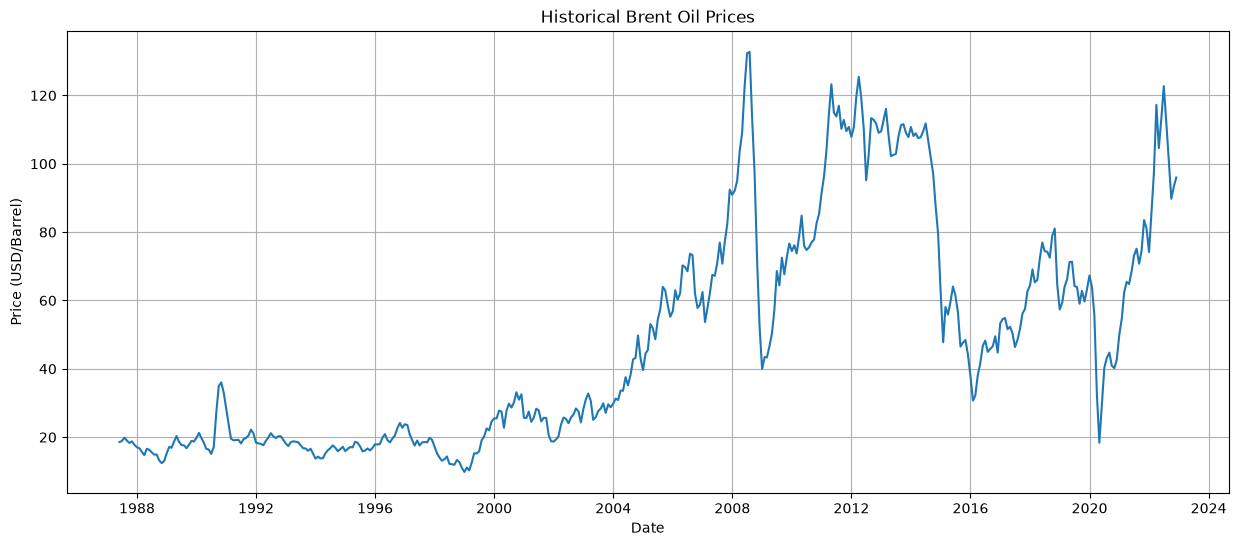

Computing log returns...
Plotting log returns...


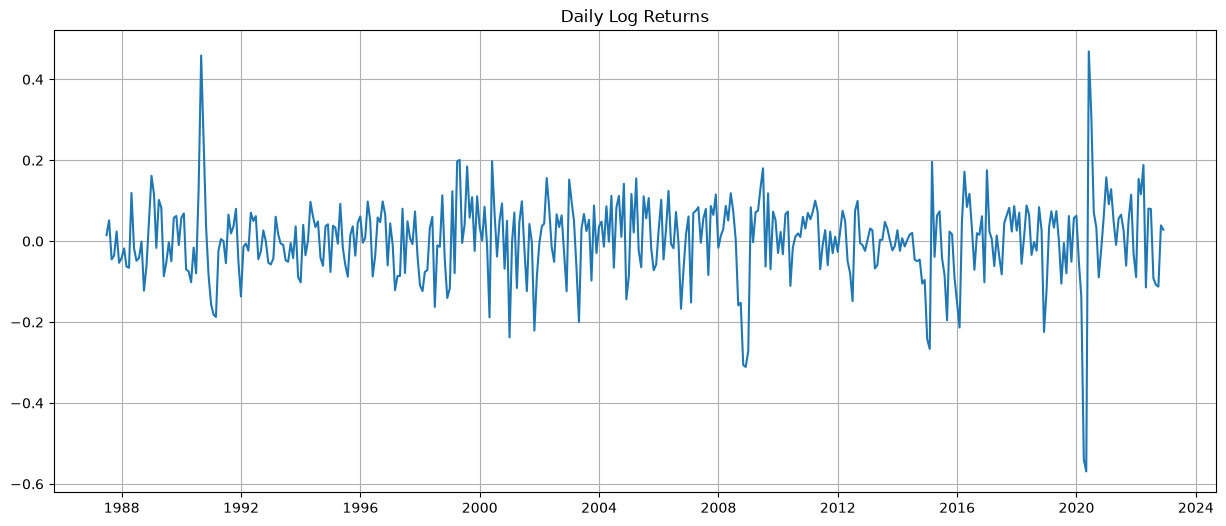

Rolling statistics...


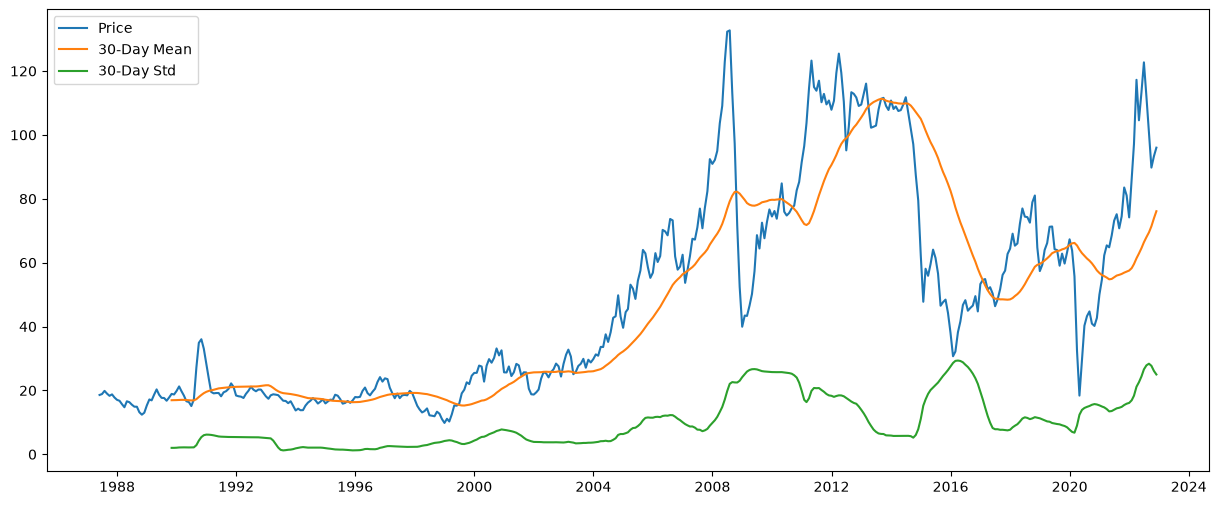

Running Bayesian model...
Number of observations: 427
Starting MCMC sampling...


Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


C:\Users\Soret\Brent-Oil-Price-Analysis1\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 2319 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Sampling completed in 2341.55 seconds.
Model finished!
          mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
tau    214.990  1.899  211.000  218.000      0.451    0.267      18.0   
mu1     21.427  1.250   19.487   23.669      0.126    0.086     108.0   
mu2     75.612  1.151   73.138   77.257      0.113    0.116      95.0   
sigma   18.672  0.636   17.557   19.954      0.040    0.070     289.0   

       ess_tail  r_hat  
tau        21.0   1.07  
mu1       120.0   1.05  
mu2        65.0   1.02  
sigma      94.0   1.03  


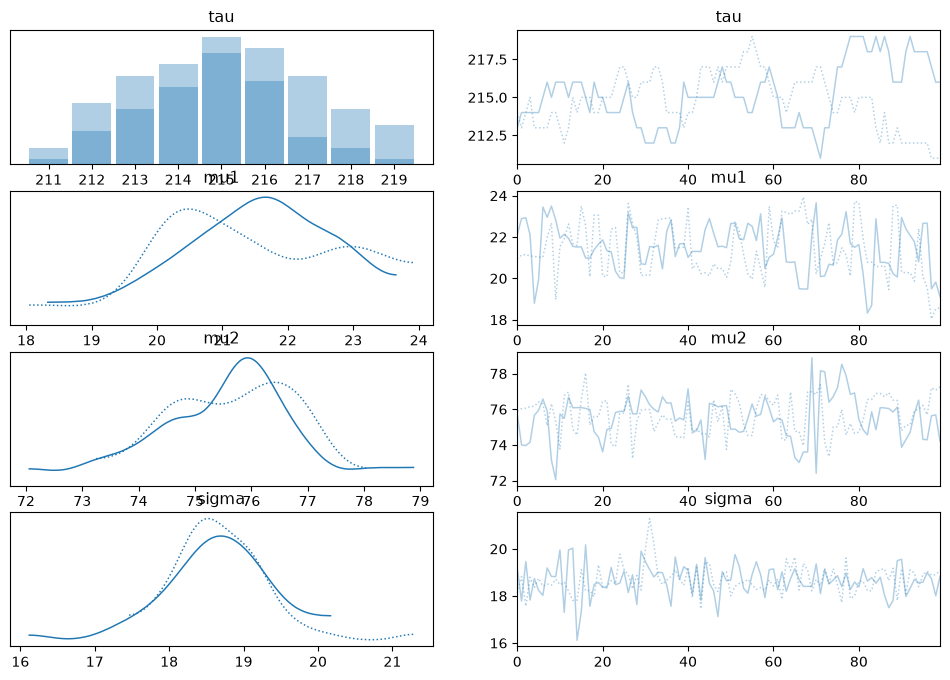

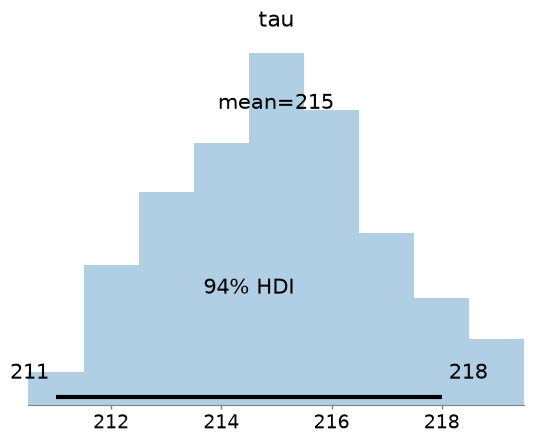

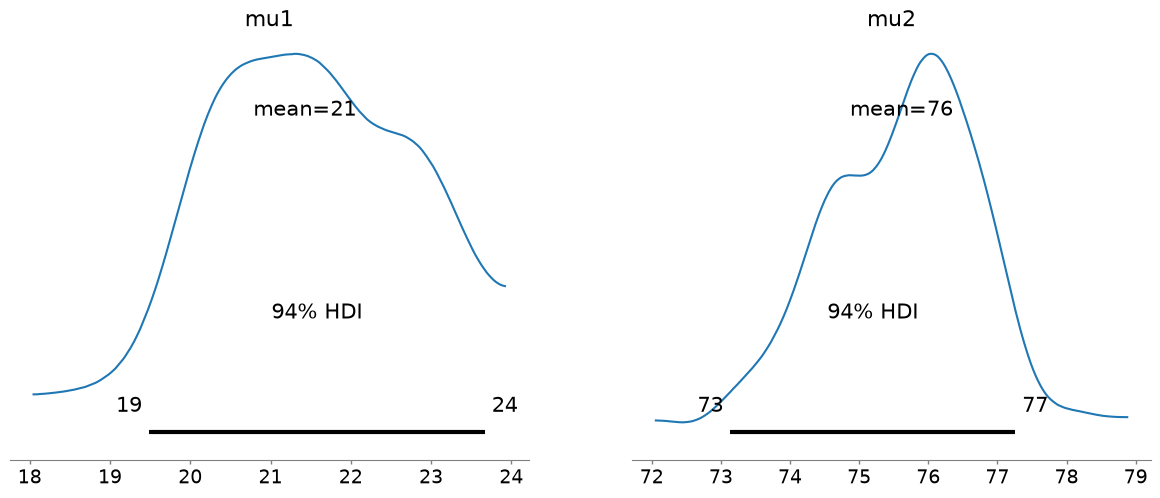

In [7]:
from src.data_loader import load_data
from src.eda import *
from src.bayesian_model import run_bayesian_model
from src.interpretation import *

print("Loading data...")
df = load_data("data/BrentOilPrices.csv")

print("Plotting prices...")
plot_price(df)

print("Computing log returns...")
df = compute_log_returns(df)

print("Plotting log returns...")
plot_log_returns(df)

print("Rolling statistics...")
rolling_statistics(df)

print("Running Bayesian model...")
trace = run_bayesian_model(df)

print("Model finished!")

summary(trace)
trace_plot(trace)
posterior_tau(trace)
posterior_means(trace)

In [8]:
import numpy as np

tau = trace.posterior["tau"].values.flatten()

estimated_tau = int(np.mean(tau))

print("Estimated Index:", estimated_tau)

print(df.iloc[estimated_tau])

Estimated Index: 214
Date          2005-03-31 00:00:00
Price                   53.104545
Log_Return                 0.1551
Name: 214, dtype: object


In [10]:
before = df.iloc[:estimated_tau]

after = df.iloc[estimated_tau:]

before_mean = before["Price"].mean()

after_mean = after["Price"].mean()

change = ((after_mean-before_mean)/before_mean)*100

print(before_mean)

print(after_mean)

print(change)

21.38705718338765
75.79704076326854
254.40612569242919
